# Feature scaling - Normalization using wine dataset

In [1]:
# Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
# Load the dataset
from sklearn.datasets import load_wine

In [8]:
wine=load_wine(as_frame=True)

#complete dataframe
df=wine.frame

In [9]:
df.columns

Index(['alcohol', 'malic_acid', 'ash', 'alcalinity_of_ash', 'magnesium',
       'total_phenols', 'flavanoids', 'nonflavanoid_phenols',
       'proanthocyanins', 'color_intensity', 'hue',
       'od280/od315_of_diluted_wines', 'proline', 'target'],
      dtype='object')

In [10]:
X=df[['alcohol','malic_acid']]
y=df[['target']]

<Axes: xlabel='alcohol', ylabel='Density'>

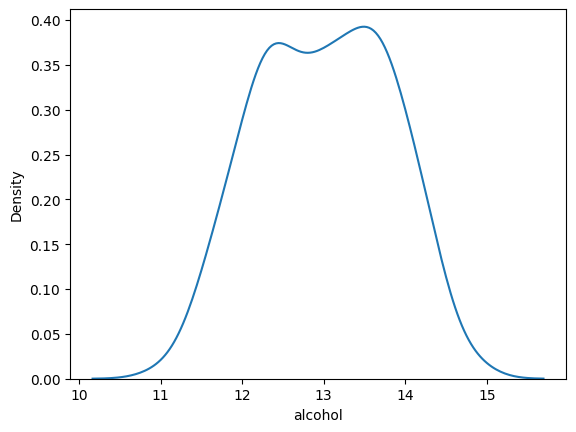

In [11]:
sns.kdeplot(df['alcohol'])

<Axes: xlabel='malic_acid', ylabel='Density'>

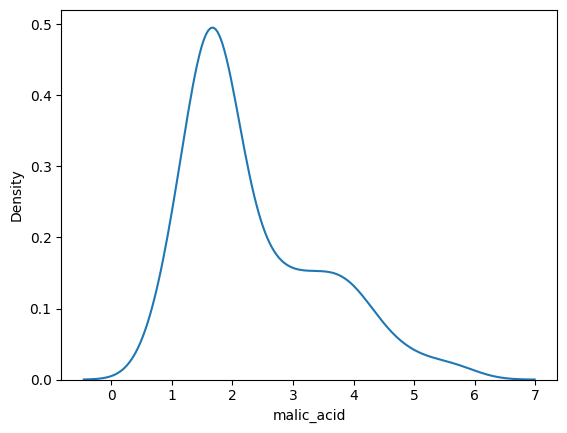

In [12]:
sns.kdeplot(df['malic_acid'])

<Axes: xlabel='alcohol', ylabel='malic_acid'>

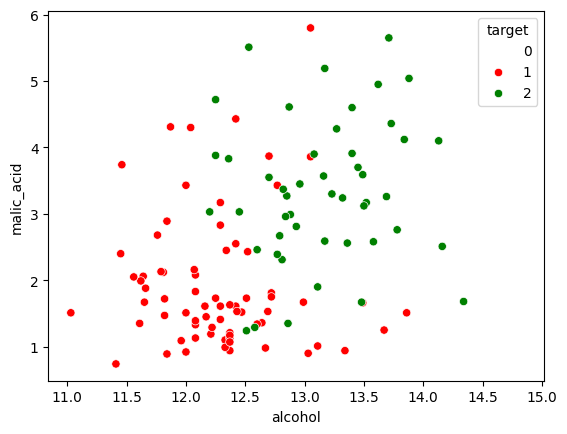

In [39]:
color_dict={1:'red',2:'green',3:'blue'}
sns.scatterplot(data=df,
                x='alcohol',
                y='malic_acid',
                hue=df['target'],
                palette=color_dict)

In [31]:
# Split Features and target
# Split into train and test
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(df[['alcohol','malic_acid']],
                                                    df['target'],
                                                    test_size=0.3,
                                                    random_state=0)

In [32]:
# Apply MinMaxScaling
from sklearn.preprocessing import MinMaxScaler
scaler=MinMaxScaler()

# fit the scaler to the train set, it will learn the parameters
scaler.fit(X_train)

# Transform train and test set
X_train_scaled=scaler.transform(X_train)
X_test_scaled=scaler.transform(X_test)

In [33]:
X_train_scaled=pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_test_scaled=pd.DataFrame(X_test_scaled, columns=X_test.columns)

In [34]:
np.round(X_train.describe(), 1)

,alcohol,malic_acid
count,124.0,124.0
mean,13.0,2.4
std,0.8,1.1
min,11.0,0.9
25%,12.4,1.6
50%,13.0,1.9
75%,13.6,3.2
max,14.8,5.6


In [35]:
np.round(X_train_scaled.describe(), 1)

,alcohol,malic_acid
count,124.0,124.0
mean,0.5,0.3
std,0.2,0.2
min,0.0,0.0
25%,0.4,0.2
50%,0.5,0.2
75%,0.7,0.5
max,1.0,1.0


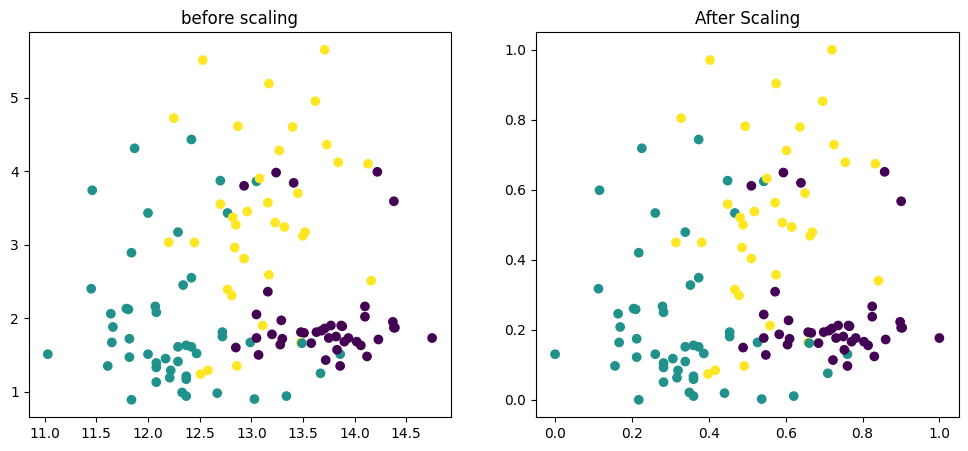

In [44]:
# plotting scatterplot for both scaled or non scaled situation
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12,5))

ax1.set_title("before scaling")
ax1.scatter(X_train['alcohol'],X_train['malic_acid'], c=y_train)

ax2.set_title("After Scaling")
ax2.scatter(X_train_scaled['alcohol'], X_train_scaled['malic_acid'],c=y_train)

plt.show()

<Axes: title={'center': 'After scaling'}, xlabel='alcohol', ylabel='Density'>

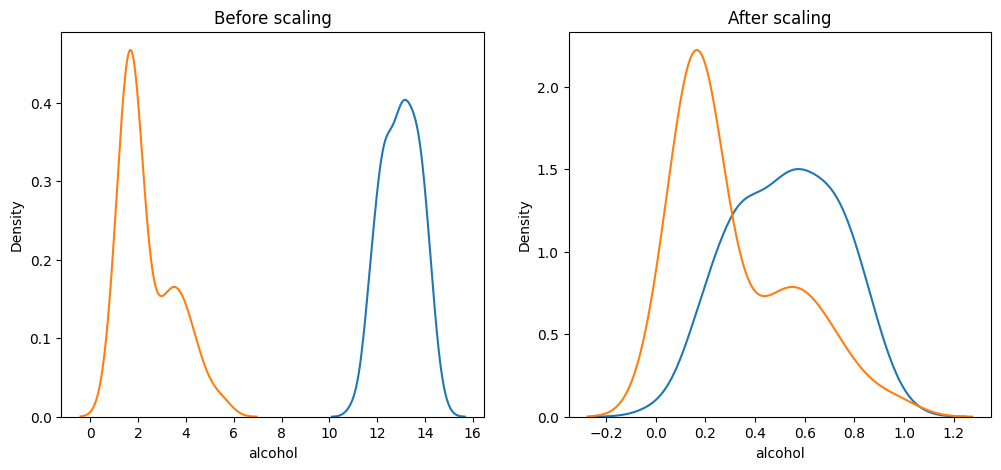

In [45]:
# plotting kdeplot for both scaled or non scaled situation
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12,5))

ax1.set_title("Before scaling")
sns.kdeplot(X_train['alcohol'],ax=ax1)
sns.kdeplot(X_train['malic_acid'],ax=ax1)

ax2.set_title("After scaling")
sns.kdeplot(X_train_scaled['alcohol'],ax=ax2)
sns.kdeplot(X_train_scaled['malic_acid'],ax=ax2)

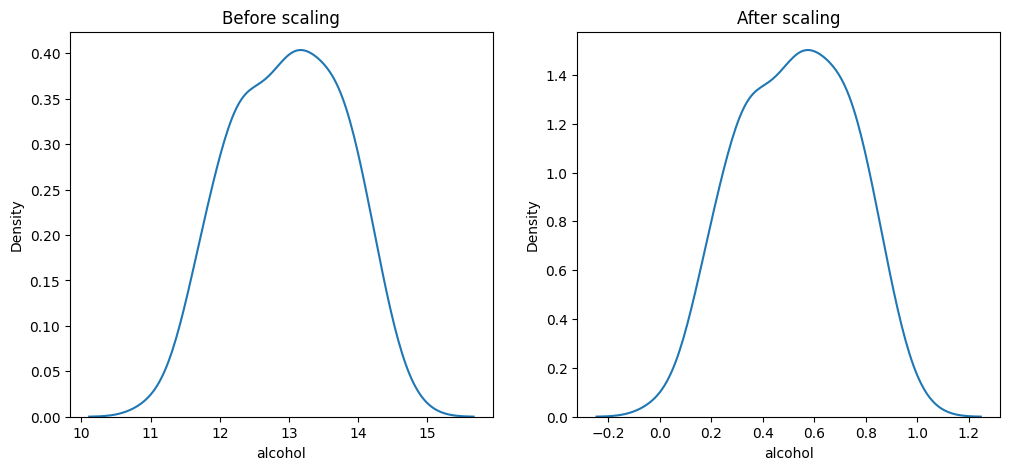

In [49]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12,5))
# Before scaling
ax1.set_title("Before scaling")
sns.kdeplot(X_train['alcohol'],ax=ax1)

# After scaling
ax2.set_title("After scaling")
sns.kdeplot(X_train_scaled['alcohol'], ax=ax2)

plt.show()

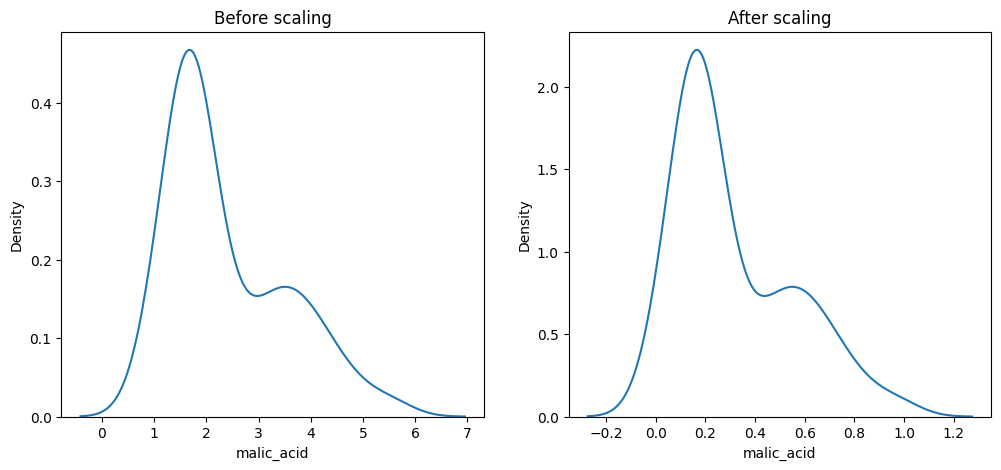

In [50]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12,5))
# Before scaling
ax1.set_title("Before scaling")
sns.kdeplot(X_train['malic_acid'],ax=ax1)

# After scaling
ax2.set_title("After scaling")
sns.kdeplot(X_train_scaled['malic_acid'], ax=ax2)

plt.show()